# PWESuite Panphon Embedding Visualization

This notebook explores the phoneme embeddings generated from:

- `main/embeddings/pictureNaming extended all/pwesuite_panphon_embeddings.pk`

We visualize the space in several ways:

1. PCA (2D + 3D)
2. t-SNE (2D)
3. Interactive scatter with hover labels
4. Cosine-similarity heatmaps
5. Nearest-neighbor lookup
6. K-means cluster maps

In [10]:
from pathlib import Path
import pickle
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans

import plotly.express as px
import plotly.graph_objects as go

sns.set_theme(style="whitegrid", context="talk")
np.random.seed(42)
random.seed(42)

In [50]:
embedding_relpaths = [
    Path("main/embeddings/pictureNaming extended all/pwesuite_panphon_embeddings.pk"),
    Path("embeddings/pictureNaming extended all/pwesuite_panphon_embeddings.pk"),
]

search_roots = [Path.cwd(), *Path.cwd().parents]
checked_paths = []
emb_path = None

for root in search_roots:
    for relpath in embedding_relpaths:
        candidate = (root / relpath).resolve()
        checked_paths.append(candidate)
        if candidate.exists():
            emb_path = candidate
            break
    if emb_path is not None:
        break

if emb_path is None:
    searched = "\n".join(f"- {path}" for path in checked_paths)
    raise FileNotFoundError(
        "Could not find pwesuite_panphon_embeddings.pk. Checked:\n" + searched
    )

with emb_path.open("rb") as f:
    data = pickle.load(f)

words = np.array(data["words"])
ipa = np.array(data["ipa"])
X = np.array(data["phoneme_embedding"], dtype=np.float32)

df = pd.DataFrame({
    "word": words,
    "ipa": ipa,
    "word_len": [len(w) for w in words],
})

print(f"Loaded embeddings from: {emb_path}")
print(f"Embedding shape: {X.shape}")
print(f"IPA backend: {data.get('ipa_backend')}")
print(f"Feature backend: {data.get('feature_backend')}")
df.head()

Loaded embeddings from: D:\OneDrive - Northwestern University\PycharmProjects\Speech\main\embeddings\pictureNaming extended all\pwesuite_panphon_embeddings.pk
Embedding shape: (168, 300)
IPA backend: eng_to_ipa
Feature backend: panphon


,word,ipa,word_len
0,airplane,ɛrpleɪn,8
1,apple,æpəl,5
2,banana,bənænə,6
3,bat,bæt,3
4,bat1,bæt,4


In [51]:
# Standardize once for downstream methods
scaler = StandardScaler()
Xz = scaler.fit_transform(X)

df.sample(8, random_state=42)

,word,ipa,word_len
137,park2,pɑrk,5
30,hand,hænd,4
119,fig,fɪ,3
29,hammer,hæmər,6
142,kale,keɪl,4
161,black,blæk,5
164,move,muv,4
51,nail1,neɪl,5


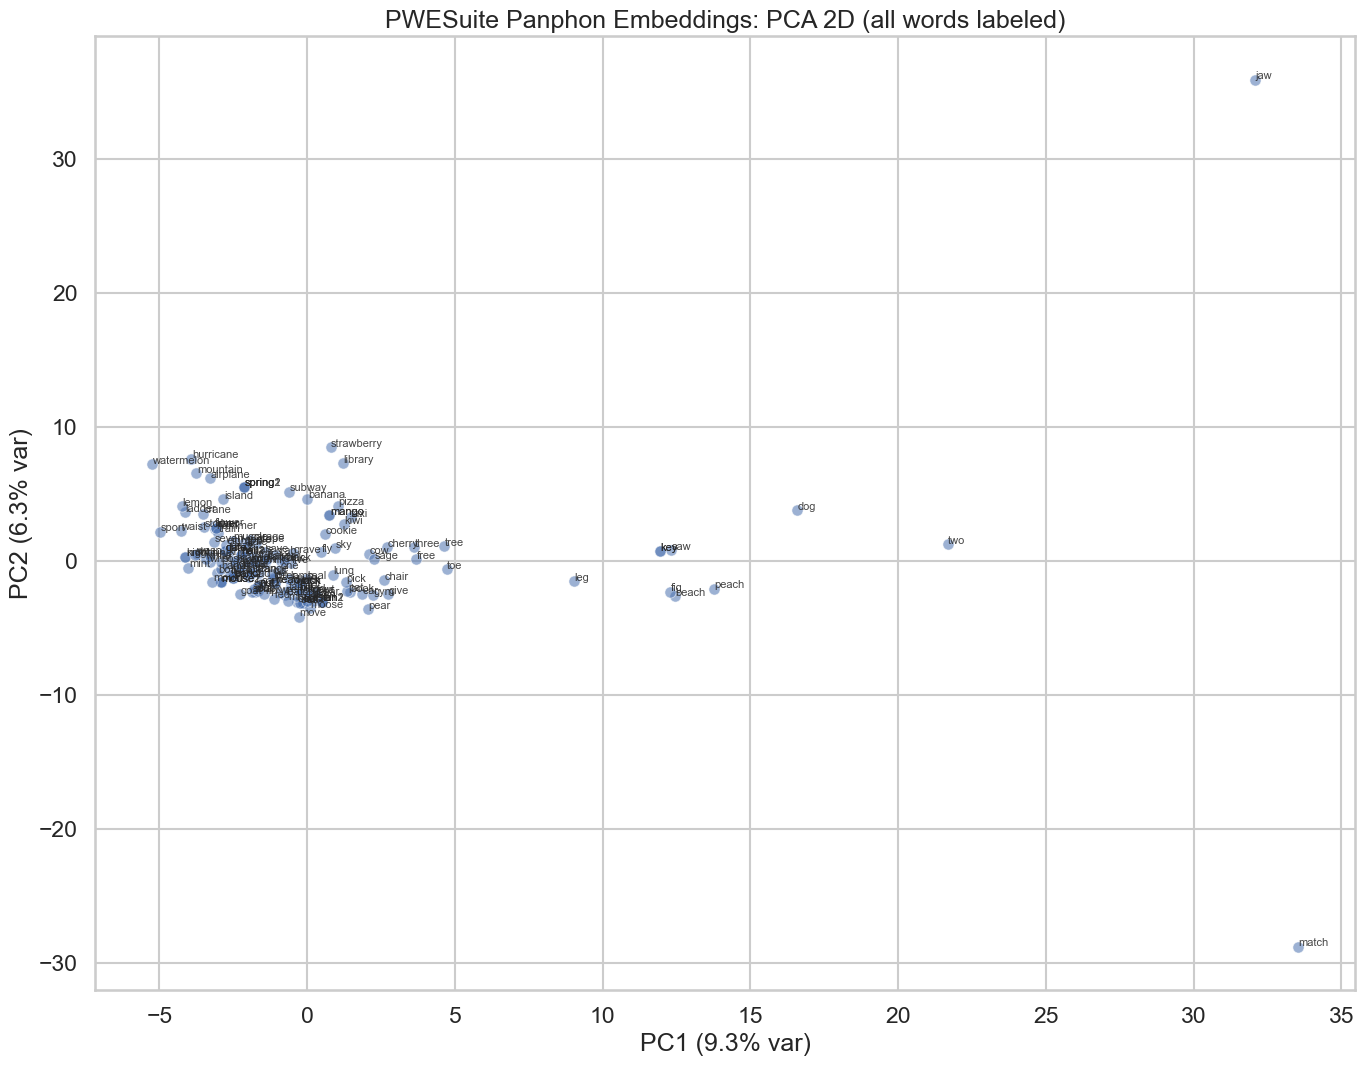

In [52]:
# 2D PCA with all words labeled
pca2 = PCA(n_components=2, random_state=42)
pcs2 = pca2.fit_transform(Xz)

df["pc1"] = pcs2[:, 0]
df["pc2"] = pcs2[:, 1]

plt.figure(figsize=(14, 11))
ax = sns.scatterplot(
    data=df,
    x="pc1",
    y="pc2",
    alpha=0.55,
    s=65,
    color="#4c72b0",
)

for _, row in df.iterrows():
    ax.text(
        row["pc1"] + 0.02,
        row["pc2"] + 0.02,
        row["word"],
        fontsize=8,
        alpha=0.85,
    )

ax.set_title("PWESuite Panphon Embeddings: PCA 2D (all words labeled)")
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)")
plt.tight_layout()
plt.show()

In [57]:
# t-SNE with all words labeled (interactive)
tsne = TSNE(
    n_components=2,
    perplexity=25,
    learning_rate="auto",
    init="pca",
    max_iter=1500,
    random_state=42,
)
tsne_xy = tsne.fit_transform(Xz)

df["tsne1"] = tsne_xy[:, 0]
df["tsne2"] = tsne_xy[:, 1]

fig = px.scatter(
    df,
    x="tsne1",
    y="tsne2",
    text="word",
    hover_data=["word", "ipa", "word_len"],
    title="PWESuite Panphon Embeddings: t-SNE (all words labeled)",
    width=1300,
    height=900,
)
fig.update_traces(
    marker=dict(size=8, opacity=0.75, line=dict(width=0.4, color="white")),
    textposition="top center",
    textfont=dict(size=9),
)
fig.show()

In [58]:
# 3D t-SNE interactive view with word labels
tsne3 = TSNE(
    n_components=3,
    perplexity=25,
    learning_rate="auto",
    init="pca",
    max_iter=1500,
    random_state=42,
)
tsne3_xyz = tsne3.fit_transform(Xz)

df["tsne3_1"] = tsne3_xyz[:, 0]
df["tsne3_2"] = tsne3_xyz[:, 1]
df["tsne3_3"] = tsne3_xyz[:, 2]

fig3 = px.scatter_3d(
    df,
    x="tsne3_1",
    y="tsne3_2",
    z="tsne3_3",
    text="word",
    hover_data=["word", "ipa", "word_len"],
    title="PWESuite Panphon Embeddings: t-SNE 3D (all words labeled)",
    width=1300,
    height=900,
)
fig3.update_traces(
    marker=dict(size=4, opacity=0.75),
    textposition="top center",
    textfont=dict(size=8),
)
fig3.show()


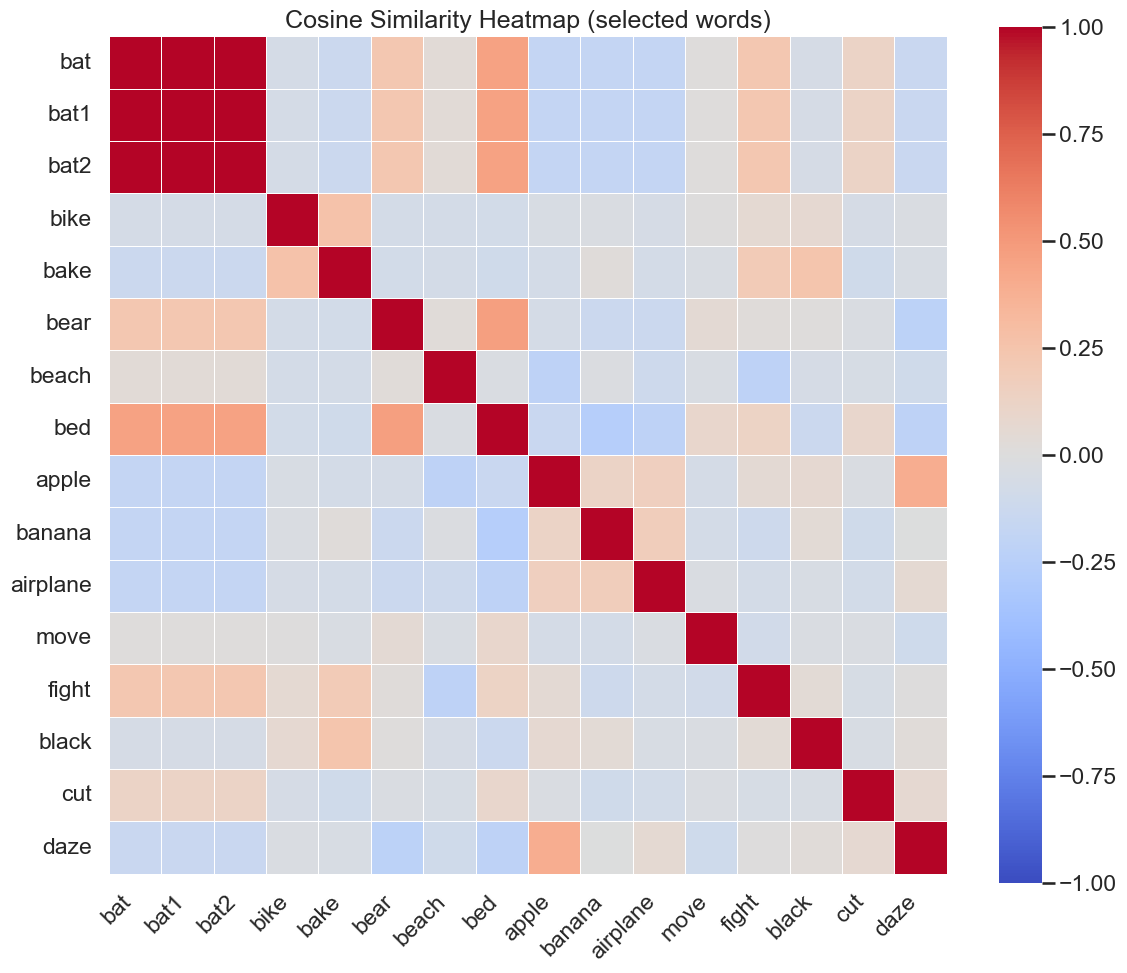

In [55]:
# Cosine similarity heatmap for a curated subset
subset_words = [
    "bat", "bat1", "bat2", "bike", "bake", "bear", "beach", "bed",
    "apple", "banana", "airplane", "move", "fight", "black", "cut", "daze",
]

word_to_idx = {w: i for i, w in enumerate(df["word"]) }
keep = [w for w in subset_words if w in word_to_idx]
idx = [word_to_idx[w] for w in keep]

sim = cosine_similarity(Xz[idx])

plt.figure(figsize=(12, 10))
sns.heatmap(
    sim,
    xticklabels=keep,
    yticklabels=keep,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    
)
plt.title("Cosine Similarity Heatmap (selected words)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [37]:
# Nearest-neighbor explorer by cosine similarity
all_sim = cosine_similarity(Xz)


def nearest_words(query_word: str, top_k: int = 8):
    if query_word not in word_to_idx:
        raise ValueError(f"Word '{query_word}' not found.")

    q = word_to_idx[query_word]
    sims = all_sim[q].copy()
    sims[q] = -np.inf
    nn_idx = np.argsort(sims)[::-1][:top_k]

    return pd.DataFrame({
        "query": query_word,
        "neighbor": words[nn_idx],
        "neighbor_ipa": ipa[nn_idx],
        "cosine_similarity": sims[nn_idx],
    })

pd.concat([
    nearest_words("bat", top_k=8),
    nearest_words("apple", top_k=8),
    nearest_words("airplane", top_k=8),
], ignore_index=True)

,query,neighbor,neighbor_ipa,cosine_similarity
0,bat,bat2,bæt,1.000000
1,bat,bat1,bæt,1.000000
2,bat,bear,bɛr,0.999041
3,bat,beach,biʧ,0.992792
4,bat,bus,bəs,0.954926
5,bat,book,bʊk,0.940321
6,bat,bed,bɛd,0.936727
7,bat,bean,bin,0.897395
8,apple,wrench,rɛnʧ,0.714253
9,apple,race,reɪs,0.711219


c:\Users\Owner\miniconda3\envs\Speech\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



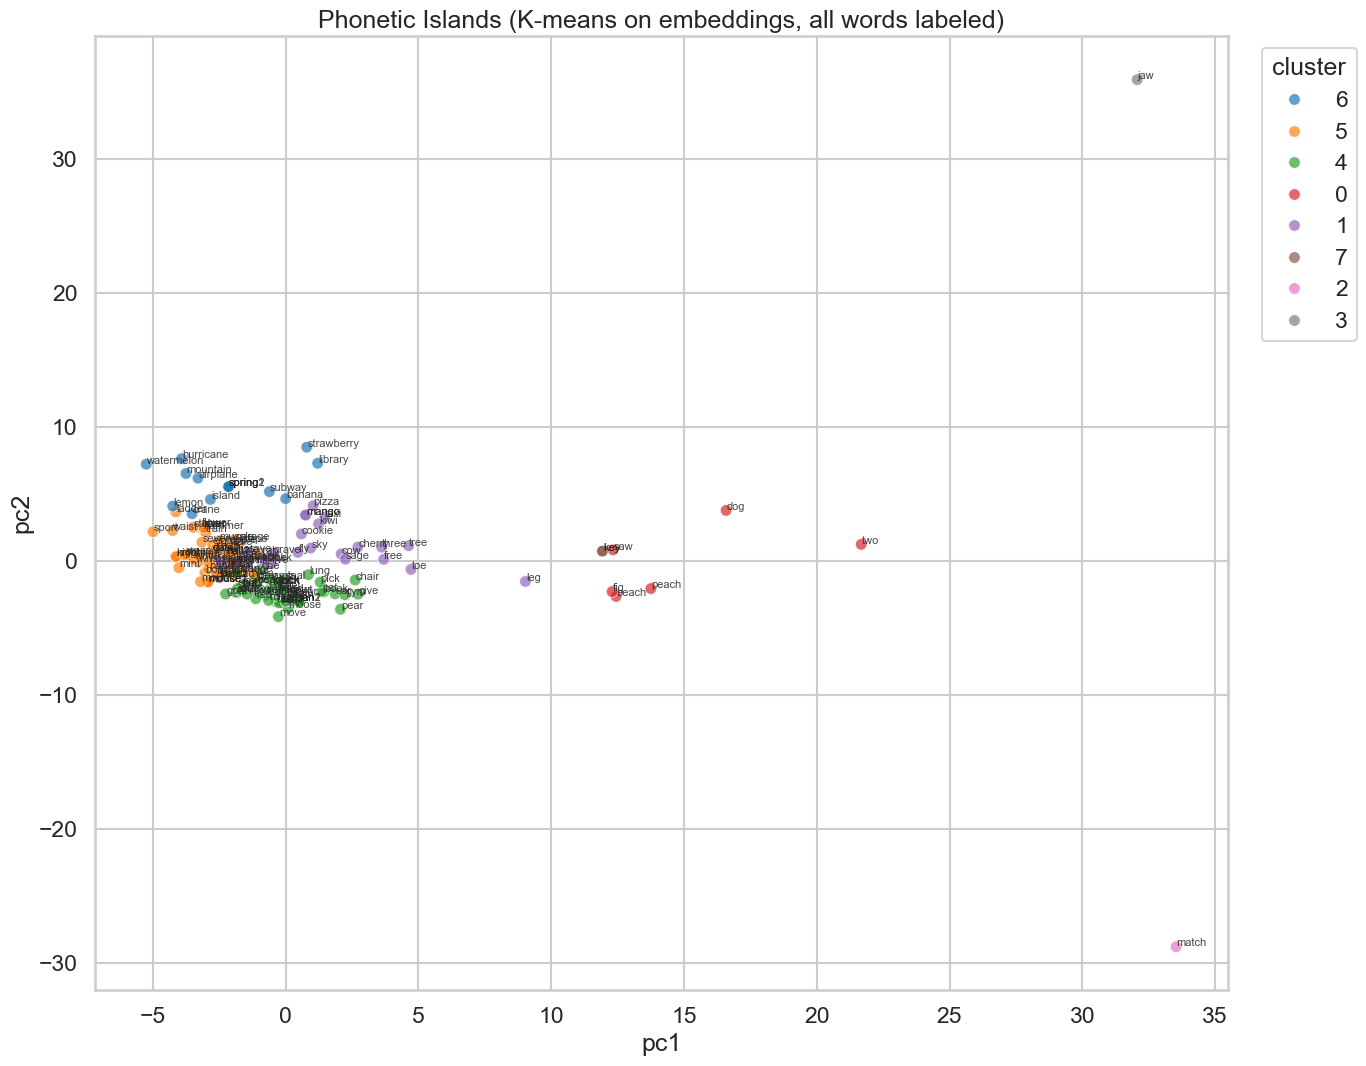

,sample_words
cluster,
0,"beach, dog, fig, peach, saw, two"
1,"bake, bank, bike, black, cherry, cookie, cow, ..."
2,match
3,jaw
4,"bat, bat1, bat2, bean, bear, bed, book, bus, c..."
5,"apple, bird, boat, can, cat, crab, cut, date, ..."
6,"airplane, banana, crane, hurricane, island, le..."
7,"key, key"


In [56]:
# K-means "phonetic islands" on top of PCA with all words labeled
n_clusters = 8
kmeans = KMeans(n_clusters=n_clusters, n_init=25, random_state=42)
clusters = kmeans.fit_predict(Xz)
df["cluster"] = clusters.astype(str)

plt.figure(figsize=(14, 11))
ax = sns.scatterplot(
    data=df,
    x="pc1",
    y="pc2",
    hue="cluster",
    palette="tab10",
    s=70,
    alpha=0.7,
)
ax.set_title("Phonetic Islands (K-means on embeddings, all words labeled)")

for _, row in df.iterrows():
    ax.text(
        row["pc1"] + 0.02,
        row["pc2"] + 0.02,
        row["word"],
        fontsize=8,
        alpha=0.85,
    )

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="cluster")
plt.tight_layout()
plt.show()

cluster_summary = (
    df.groupby("cluster")["word"]
      .apply(lambda s: ", ".join(sorted(s.tolist())[:10]))
      .to_frame(name="sample_words")
)
cluster_summary